# 24 - Perturbation-level consistency: the non-evolving Einstein equation

The same trick as `22_test_acceleration_equation.ipynb`, one level up. Nothing is differentiated.

**The structure of the test.** In synchronous gauge there are four scalar Einstein equations for two
metric functions $h,\eta$. Two are redundant given stress-energy conservation, so CLASS imposes two
and never evaluates the other two:

| Ma & Bertschinger | what CLASS does | where |
|---|---|---|
| (21a) energy constraint | **imposed**, used to set $h'$ | `perturbations.c:6876` |
| (21b) momentum constraint | **imposed**, used to set $\eta'$ | `perturbations.c:6900` |
| (21c) trace | computed at `perturbations.c:6905`, but **never used to evolve** $h'$ | - |
| (21d) traceless $ij$ | never evaluated | - |

So the residual of (21a) is zero by construction and carries no information - exactly as the audit
brief warned. The one to integrate is **(21c)**.

Note the precise claim about (21c): CLASS *does* evaluate it, at `perturbations.c:6905`, to fill
`index_mt_h_prime_prime` for use in source terms. What it never does is use it to evolve $h'$ - $h'$
is recomputed from the constraint (21a) at every step. So $h''$ from (21c) and $h'$ from (21a) are
independent outputs, and they agree only if stress-energy is conserved. That is the whole test.
(A useful side effect: CLASS's own line has the identical coefficient $9a^2\delta p$ and identical
signs to the expression derived below, which is an independent check of the algebra.)

**Deriving what it should equal.** From CLASS's own form of the energy constraint
($s_2=1$, $K=0$, CLASS density units where $\rho$ already carries $8\pi G/3$):

$$\tfrac12\mathcal{H}h' = k^2\eta + \tfrac32 a^2\delta\rho_{\rm tot}. \tag{E1}$$

Differentiate it in $\tau$, substitute the momentum constraint $k^2\eta' = \tfrac32 a^2(\rho+p)\theta$
and the *total* energy continuity equation

$$\delta\rho_{\rm tot}' = -3\mathcal{H}(\delta\rho_{\rm tot}+\delta p_{\rm tot})
-(\rho+p)\bigl(\theta + \tfrac{h'}{2}\bigr) + \sum_i \delta Q_i ,$$

then eliminate $\delta\rho$ with (E1) again and use the background identities
$\mathcal{H}' = -\tfrac12 a^2(\rho+3p)$, $\mathcal{H}^2 = a^2\rho$. The $h'$ coefficients collapse
($\mathcal{H}'/\mathcal{H} + \tfrac32 a^2(\rho+p)/\mathcal{H} = \mathcal{H}$) and everything reduces to

$$\boxed{\;h'' + 2\mathcal{H}h' - 2k^2\eta + 9a^2\delta p_{\rm tot} \;=\; \frac{3a^2}{\mathcal{H}}\sum_i \delta Q_i\;}$$

The left side is Ma & Bertschinger (21c) in CLASS units ($24\pi G a^2\delta P_{\rm phys} = 9a^2\delta p_{\rm code}$).
The right side is **zero for any conserved model**, and for accDM it is the perturbed image of the
background violation, since the parent loses $-a\Gamma\rho_c\delta_c$ (`perturbations.c:9907`) while
the daughter gains $+(1+\eta_{\rm acc})a\Gamma\rho_c\delta_c$ (`perturbations.c:10190`):

$$\sum_i \delta Q_i \;=\; \eta_{\rm acc}\,a\,\Gamma_{\rm acc}\,\rho_{\rm parent}\,\delta_{\rm parent}.$$

**The auxiliary integration.** Exactly as in the background case, and again a quadrature rather than
an ODE because the right-hand side never contains $h'_B$:

$$h'_B(\tau) = h'_A(\tau_0) + \int_{\tau_0}^{\tau}\Bigl[-2\mathcal{H}h'_A + 2k^2\eta - 9a^2\delta p_{\rm tot}\Bigr]\mathrm{d}\tau',$$

where $h'_A$ is the code's own `h_prime`, obtained from the imposed constraint. The reported drift is

$$\Delta_h(\tau) \;=\; \frac{h'_B - h'_A}{\max_{\tau'\le\tau}|h'_A|},$$

normalised by a running envelope rather than by $h'_A$ itself, so that modes whose $h'$ passes
through zero do not produce spurious poles.


## Prerequisite: two lines in `perturbations.c`

This notebook needs `delta_p_tot` in the `k_output` columns, and it needs an existing column-order bug
fixed. Both are **output-only** changes - no physics is touched.

**(a) `eta` and `delta_rho_tot` are currently swapped.** Titles are appended in the order
`rho_plus_p_theta, delta_rho_tot, eta` (`perturbations.c:3350-3352`) but the data in the order
`rho_plus_p_theta, eta, delta_rho` (`perturbations.c:9085-9087`). Both are sequential appends, so in
synchronous gauge `get_perturbations()['delta_rho_tot']` returns $\eta$ and `['eta']` returns
$\delta\rho_{\rm tot}$. Newtonian gauge is unaffected (the `eta` entry is skipped in both lists).

In `perturbations_print_variables`, around line 9085, reorder to match the titles and add the new
column:

```c
    class_store_double(dataptr, ppw->rho_plus_p_theta, _TRUE_, storeidx);
    class_store_double(dataptr, ppw->delta_rho, _TRUE_, storeidx);                     /* moved up */
    class_store_double(dataptr, y[ppw->pv->index_pt_eta],
                       ppt->gauge == synchronous, storeidx);                           /* moved down */
    class_store_double(dataptr, ppw->delta_p, _TRUE_, storeidx);                       /* NEW */
```

**(b) declare the new title.** In the `k_output_values_num > 0` block, after the `eta` entry
(`perturbations.c:3352`):

```c
    class_store_columntitle(ppt->scalar_titles, "delta_p_tot", _TRUE_);                /* NEW */
```

`ppw->delta_p` is already the complete total - photons, ur, idr, dr, both ncdm branches (exact and
fluid), scf and fld, plus the RSA corrections - accumulated in `perturbations_total_stress_energy`
alongside `ppw->delta_rho`. Nothing new is computed.

The first cell below verifies both changes landed, using an identity that cannot pass if the columns
are mislabelled.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

try:
    from scipy.interpolate import CubicSpline
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

plt.rcParams.update({
    'mathtext.fontset': 'stix',
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628']

omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
A_REC = 1.0/(1.0 + 1090.0)

K_OUT        = [0.01, 0.1, 1.0]    # 1/Mpc
A_START      = 1e-3
FIDUCIAL     = dict(f_acc=0.1, eta=0.1, kappa=12.1, a_t=0.133)

# Always use the Runge-Kutta evolver. CLASS defaults to ndf15, whose Jacobian
# handling OOMs / integer-overflows once the ncdm hierarchy gets large, and the
# accDM daughter contributes q_size*(l_max_ncdm+1) equations - 250 bins is ~4500
# for the daughter alone, which kills the kernel outright (no Python traceback).
EVOLVER      = 0       # 0 = rk, 1 = ndf15

# Approximation schemes.
#
# RSA and UFA are photon / ultra-relativistic closures. They have nothing to do
# with accDM, so they are left at CLASS's production defaults and never touched.
#
# The ncdm fluid approximation IS part of the model under test - it is the closure
# applied to the accDM daughter - so it is exposed here as a single knob and
# applied IDENTICALLY to the LCDM null and the accDM run. That is what makes the
# null a null: both legs must use the same closure, or the floor measured on one
# does not bound the error on the other.
#
#   'none'  -> exact Boltzmann hierarchy for every ncdm species (slower)
#   'CLASS' -> CLASS's ncdmfa closure, i.e. the production configuration
NCDM_FLUID   = 'none'
NCDMFA_INDEX = {'none': 3, 'CLASS': 2}      # enum order, perturbations.h:47

N_Q_DAUGHTER = 501      # rk handles more, but 64 is plenty here: the test is
                       # self-consistent (whatever delta_p_tot CLASS computed is
                       # exactly what gets fed back), so the q-grid changes the
                       # model slightly and the validity of the check not at all
L_MAX_NCDM   = 17      # CLASS default; lowering it cuts neq proportionally


def common_output(params):
    params.update({'output': 'mPk', 'gauge': 'synchronous',
                   'k_output_values': ','.join(str(k) for k in K_OUT),
                   'P_k_max_1/Mpc': 2.0, 'z_max_pk': 3.0,
                   'l_max_ncdm': L_MAX_NCDM,
                   'evolver': EVOLVER})
    # applied to BOTH legs of the test; RSA/UFA left at CLASS defaults
    params['ncdm_fluid_approximation'] = NCDMFA_INDEX[NCDM_FLUID]
    return params


def hierarchy_size(params):
    '''Rough equation count, to catch an ndf15 blow-up before it kills the kernel.'''
    n_q = [int(s) for s in str(params['ncdm_N_momentum_bins']).split(',')]
    return sum(q*(L_MAX_NCDM + 1) for q in n_q) + 60


def accdm_params(f_acc, eta, kappa, a_t, mass_GeV=1e16, n_q=None):
    n_q  = N_Q_DAUGHTER if n_q is None else n_q
    ocdm = omega_cdm0*(1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q), 'N_ur': 0.00441})
    return common_output(p)


def lcdm_params():
    p = dict(base_params)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02', 'T_ncdm': '0.71611',
              'ncdm_quadrature_strategy': '0', 'ncdm_N_momentum_bins': '15',
              'N_ur': 0.00441})
    return common_output(p)


def run(params):
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    out = (cosmo.get_perturbations()['scalar'], cosmo.get_background())
    cosmo.struct_cleanup()
    cosmo.empty()
    return out


perts_l, bg_l = run(lcdm_params())
keys = sorted(perts_l[0].keys())
print('get_perturbations() keys:')
print(' ', keys)

missing = [k for k in ('delta_p_tot', 'delta_rho_tot', 'eta', 'h_prime') if k not in keys]
if missing:
    raise RuntimeError(
        'missing columns {}: apply the two-line patch above and rebuild classy'.format(missing))
print('\nall required columns present')


get_perturbations() keys:
  ['a', 'cs2_ncdm[0]', 'delta_b', 'delta_cdm', 'delta_g', 'delta_ncdm[0]', 'delta_p_tot', 'delta_rho_tot', 'delta_ur', 'eta', 'eta_prime', 'h_prime', 'k_fss_acc[0]', 'phi', 'phi_prime', 'pol0_g', 'pol1_g', 'pol2_g', 'psi', 'rho_plus_p_theta', 'shear_g', 'shear_ncdm[0]', 'shear_ur', 'tau [Mpc]', 'theta_b', 'theta_cdm', 'theta_g', 'theta_ncdm[0]', 'theta_ur', 'w_p[0]', 'w_sigma[0]', 'w_theta[0]', 'w_trial_1', 'w_trial_2']

all required columns present


## Column-mapping test

CLASS *sets* $h'$ from $\tfrac12\mathcal{H}h' = k^2\eta + \tfrac32 a^2\delta\rho_{\rm tot}$, so that
identity must hold to machine precision. That makes it a perfect test of three things at once: the
column labels, the CLASS unit convention, and the fact that (21a) carries no information.

It is also the regression test for patch (a). The residual is evaluated **both** with the columns as
labelled and with `eta`/`delta_rho_tot` interchanged, and the verdict rests on the *ratio*: the
correct ordering should beat the swapped one by many orders of magnitude.

The ratio matters because the absolute residual is interpolation-limited, not machine-limited. The
identity cancels three large terms against each other, so any error in $\mathcal{H}$ enters
undiluted, and $\mathcal{H}$ has to be interpolated from the background table onto the perturbation
sampling. Linear interpolation gives $\sim3\times10^{-7}$ even on the default 40000-point background
grid - easily mistaken for a failure. The interpolator below is cubic, which brings it to
$\sim10^{-12}$.


scipy available for interpolation: True

Energy-constraint residual  (1/2)H h' - k^2 eta - (3/2) a^2 delta_rho_tot,
normalised by the largest term. CLASS SETS h' from this equation, so the only
things that can spoil it are a column mismatch or my own reconstruction.

        k     median        p99        max max(clean)  a at max  n_dup    swapped
     0.01   4.80e-09   3.49e-06   4.04e-06   3.87e-06    0.0901      3   1.00e+00
      0.1   1.71e-09   3.24e-05   8.32e-05   8.09e-05    0.0018      3   9.94e-01
        1   3.45e-11   5.52e-07   1.53e-06   1.52e-06    0.0013      3   1.00e+00
  n_dup = samples where CLASS reprinted the same tau (approximation switches);
  max(clean) excludes those rows. If max >> max(clean), the spikes are switches.

COLUMN MAPPING : PASS
  labelled/swapped median ratio = 4.83e-09   (needs < 1e-3)
RECONSTRUCTION : clean
  worst median residual = 4.80e-09


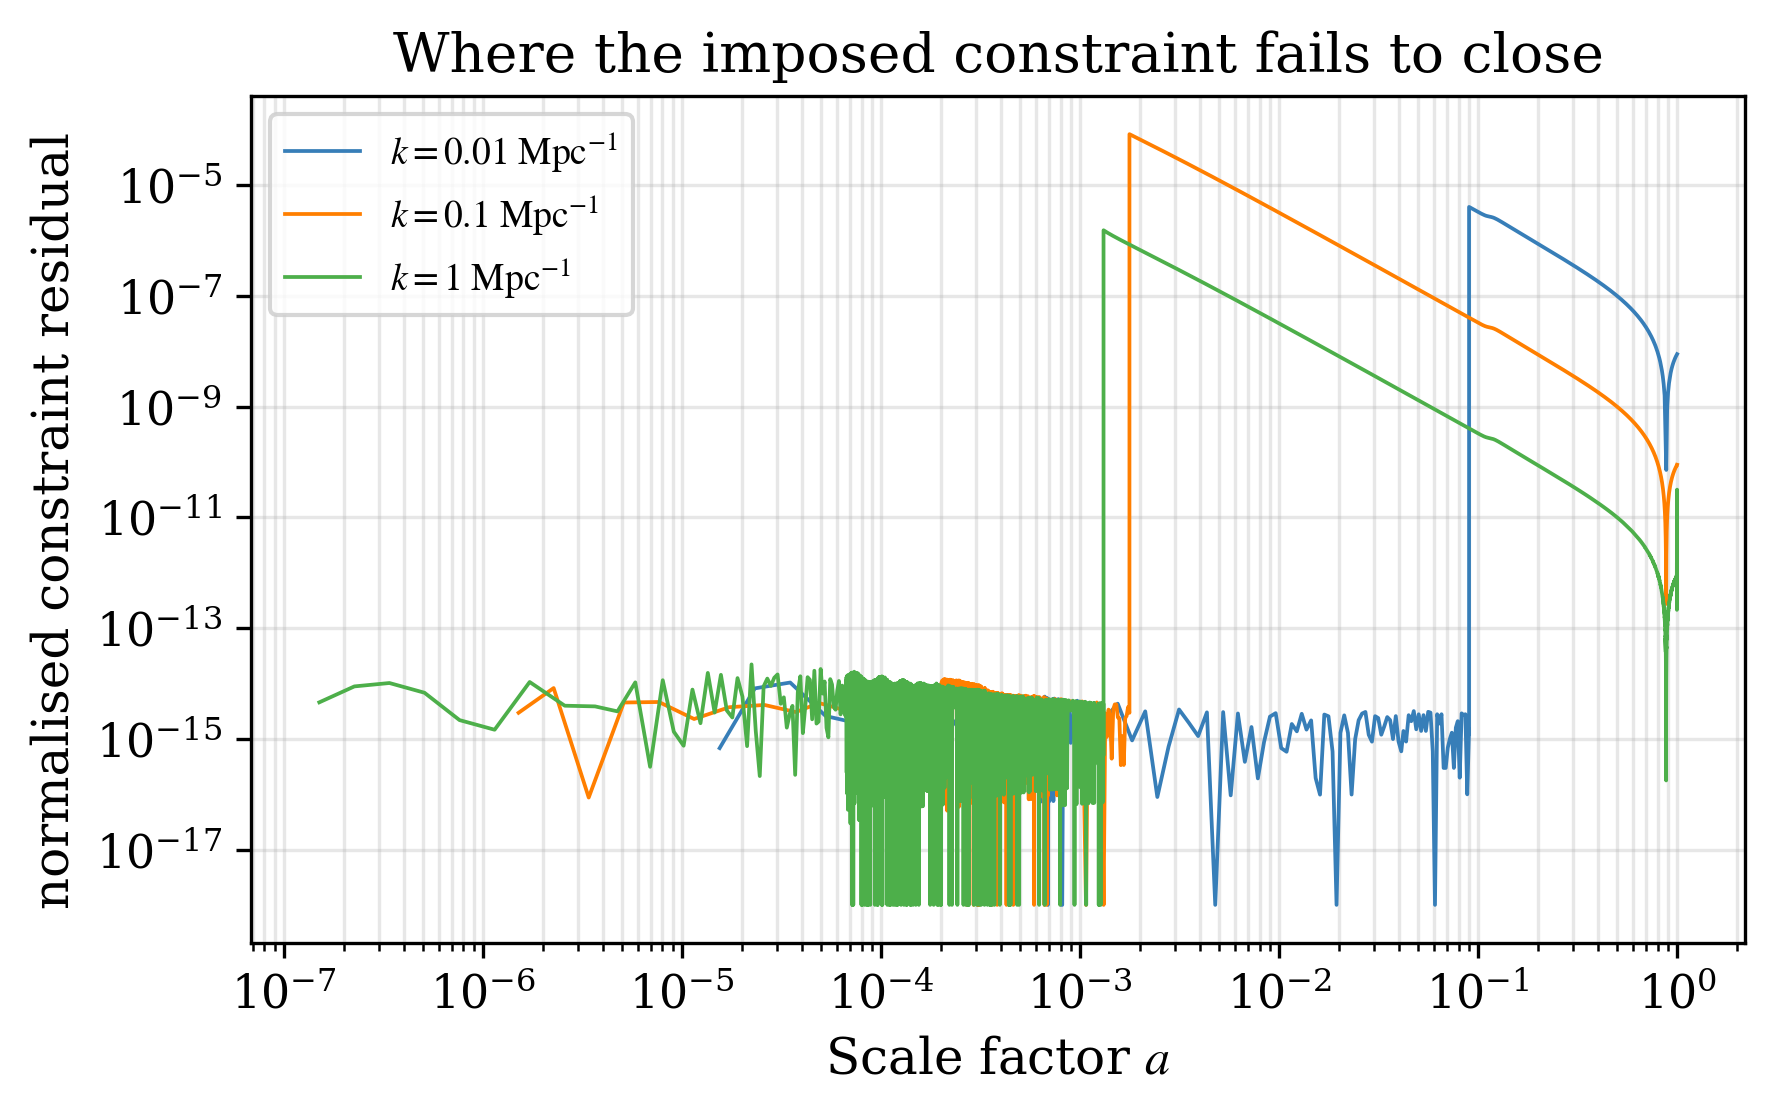

In [2]:
def bg_interp(bg):
    '''Background interpolator on ln a, CUBIC where scipy is available.

    This matters more than it looks. The constraint below cancels three large terms
    against each other, so any error in H lands directly in the residual. Linear
    np.interp on the default background_Nloga = 40000 grid (dln a = 8e-4) has a
    relative error ~(dln a)^2 ~ 3e-7, which is far above the residual being tested
    and would masquerade as a failed check. Cubic drops that to ~1e-14.'''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    ln_a  = np.log(a_all[order])
    # insurance: a spline needs strictly increasing knots
    keep      = np.ones(len(ln_a), dtype=bool)
    keep[:-1] = ln_a[1:] > ln_a[:-1]
    ln_a, order = ln_a[keep], order[keep]
    cache = {}

    def f(key, a_at):
        if key not in cache:
            col = np.asarray(bg[key])[order]
            pos = np.all(col > 0)
            # interpolate log-log for strictly positive columns: H spans 26 decades
            # and ln H vs ln a is nearly straight, so the spline error collapses
            val = np.log(col) if pos else col
            cache[key] = (pos, CubicSpline(ln_a, val) if HAVE_SCIPY else val)
        pos, obj = cache[key]
        x = np.log(a_at)
        out = obj(x) if HAVE_SCIPY else np.interp(x, ln_a, obj)
        return np.exp(out) if pos else out

    return f


def constraint_residual(perts, bg, k_list):
    '''Residual of the IMPOSED energy constraint, normalised by the largest term.

    Evaluated twice: once with the columns as labelled, once with 'eta' and
    'delta_rho_tot' interchanged. That discriminates a genuine column-mapping error
    (one ordering closes, the other is O(1)) from ordinary numerical noise (both
    similar), so the test cannot be fooled by interpolation quality.'''
    interp = bg_interp(bg)
    rows = []
    for kk, pk in zip(k_list, perts):
        a    = np.asarray(pk['a'])
        sel  = a > 1e-8
        a    = a[sel]
        col_eta  = np.asarray(pk['eta'])[sel]
        col_drho = np.asarray(pk['delta_rho_tot'])[sel]
        hp   = np.asarray(pk['h_prime'])[sel]
        Hcal = a*interp('H [1/Mpc]', a)
        t1   = 0.5*Hcal*hp

        prof = {}
        for label, (eta_s, drho) in (('normal',  (col_eta,  col_drho)),
                                     ('swapped', (col_drho, col_eta))):
            t2, t3 = -kk*kk*eta_s, -1.5*a**2*drho
            scale  = np.maximum.reduce([np.abs(t1), np.abs(t2), np.abs(t3)])
            prof[label] = np.abs(t1 + t2 + t3)/np.where(scale > 0, scale, 1.0)

        # rows where CLASS reprinted the same tau (approximation switches): the
        # evolver stops, reinitialises and prints the boundary time on both sides
        tau_k = np.asarray(pk['tau [Mpc]'])[sel]
        dup   = np.zeros(len(tau_k), dtype=bool)
        dup[1:] = np.diff(tau_k) <= 0
        dup[:-1] |= (np.diff(tau_k) <= 0)

        r = prof['normal']
        clean = r[~dup] if np.any(~dup) else r
        rows.append(dict(k=kk, a=a, prof=r, dup=dup,
                         median=float(np.median(r)),
                         p99=float(np.percentile(r, 99)),
                         max=float(np.max(r)),
                         a_at_max=float(a[int(np.argmax(r))]),
                         n_dup=int(np.sum(np.diff(tau_k) <= 0)),
                         max_clean=float(np.max(clean)),
                         swapped_median=float(np.median(prof['swapped']))))
    return rows


rows = constraint_residual(perts_l, bg_l, K_OUT)
print('scipy available for interpolation:', HAVE_SCIPY)
print()
print('Energy-constraint residual  (1/2)H h\' - k^2 eta - (3/2) a^2 delta_rho_tot,')
print('normalised by the largest term. CLASS SETS h\' from this equation, so the only')
print('things that can spoil it are a column mismatch or my own reconstruction.')
print()
print('  {:>7} {:>10} {:>10} {:>10} {:>10} {:>9} {:>6} {:>10}'.format(
      'k', 'median', 'p99', 'max', 'max(clean)', 'a at max', 'n_dup', 'swapped'))
for r in rows:
    print('  {:>7g} {:>10.2e} {:>10.2e} {:>10.2e} {:>10.2e} {:>9.4f} {:>6d} {:>10.2e}'.format(
          r['k'], r['median'], r['p99'], r['max'], r['max_clean'], r['a_at_max'],
          r['n_dup'], r['swapped_median']))
print('  n_dup = samples where CLASS reprinted the same tau (approximation switches);')
print('  max(clean) excludes those rows. If max >> max(clean), the spikes are switches.')

med_norm = max(r['median'] for r in rows)
med_swap = min(r['swapped_median'] for r in rows)

# The MAPPING verdict is the ratio: a mislabelling makes the swapped ordering the
# one that closes. Isolated spikes (approximation switches: tight-coupling off,
# RSA on, ncdm fluid on) inflate the max but not the median, and being measure-zero
# in tau they do not affect the integrated drift measured later.
columns_ok = med_norm < 1e-3*med_swap
quality_ok = med_norm < 1e-8

print('\nCOLUMN MAPPING :', 'PASS' if columns_ok else 'FAIL - columns swapped or units error')
print('  labelled/swapped median ratio = {:.2e}   (needs < 1e-3)'.format(med_norm/med_swap))
print('RECONSTRUCTION :', 'clean' if quality_ok else
      'spiky - check "a at max" against your approximation-switch times')
print('  worst median residual = {:.2e}'.format(med_norm))
assert columns_ok, 'the imposed constraint closes better with the columns SWAPPED'

fig, ax = plt.subplots(figsize=(5.8, 3.6), constrained_layout=True)
for color, r in zip(qual_colors, rows):
    ax.loglog(r['a'], np.maximum(r['prof'], 1e-18), color=color, linewidth=0.9,
              label=r'$k = {:g}\ \mathrm{{Mpc}}^{{-1}}$'.format(r['k']))
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel('normalised constraint residual')
ax.set_title('Where the imposed constraint fails to close')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## The estimator

Same shape as the background version: a cumulative quadrature of a tabulated integrand, driven by the
code's own solution. The perturbation grid is *not* uniform in $\tau$, so a spline antiderivative is
used where scipy is available and a plain cumulative trapezoid otherwise.

The predicted drift, for comparison, is the running integral of the source term with
$\sum\delta Q = \eta\,a\Gamma\rho_{\rm parent}\delta_{\rm parent}$ - the direct analogue of
$R_{\rm pred}$ in the background notebook, built from the code's own `Gamma_acc`,
`(.)rho_acc_cdm` and `delta_dcdm`.


In [3]:
def dedupe_increasing(x, *arrays):
    '''Return x strictly increasing, with the companion arrays filtered to match.

    CLASS emits the same tau twice at every approximation switch (tight-coupling
    off, RSA on, ncdm fluid on): the evolver stops, the variables are
    reinitialised, and the boundary time is printed on both sides. The k_output
    grid is therefore non-decreasing, not strictly increasing. The LAST sample at
    each tau is kept - that is the post-switch state the evolver continues from.
    Duplicates carry zero width, so dropping them cannot change any integral.'''
    order  = np.argsort(x, kind='stable')
    x      = np.asarray(x)[order]
    arrays = [np.asarray(arr)[order] for arr in arrays]
    keep        = np.ones(len(x), dtype=bool)
    keep[:-1]   = x[1:] > x[:-1]
    return x[keep], [arr[keep] for arr in arrays]


def cum_trapz(y, x):
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def cum_spline(y, x):
    F = CubicSpline(x, y).antiderivative()
    return F(x) - F(x[0])


def cum_quad(y, x):
    '''Cumulative integral - TRAPEZOID, deliberately, not a spline.

    Unlike the smooth background integrands of notebook 22, this one contains
    perturbation variables that JUMP when CLASS switches approximation scheme
    (RSA, UFA, ncdm fluid). A cubic spline through a jump rings violently and its
    antiderivative accumulates the ringing; the trapezoid rule degrades gracefully,
    with a local O(h * jump) error. quad_error() reports a Richardson error bar.'''
    return cum_trapz(y, x)


def quad_error(y, x):
    '''Richardson estimate of the trapezoid error: full grid vs every other point.

    This replaces an earlier trapezoid-vs-spline comparison, which was misleading:
    on an integrand with jumps it is the SPLINE that fails, so that number flagged
    the rule we do not use. Halving the sampling and comparing the same rule
    against itself is an error bar on the answer we actually report. Trapezoid is
    O(h^2), so the true error is ~1/3 of the difference.'''
    if len(x) < 8:
        return float('nan')
    full = cum_trapz(y, x)[-1]
    half = cum_trapz(y[::2], x[::2])[-1]
    scale = max(abs(full), 1e-300)
    return float(abs(full - half)/3.0/scale)


def trace_drift(pk, bg, k, eta_acc, a_start=A_START):
    '''Integrate MB (21c) as an auxiliary and compare with the code's own h_prime.'''
    interp = bg_interp(bg)
    has_acc = ('delta_dcdm' in pk) and ('(.)rho_acc_cdm' in bg)

    a_raw   = np.asarray(pk['a'])
    par_raw = np.asarray(pk['delta_dcdm']) if has_acc else np.zeros_like(a_raw)
    tau, (a, hp_A, eta_s, dp, delta_par) = dedupe_increasing(
        np.asarray(pk['tau [Mpc]']), a_raw,
        np.asarray(pk['h_prime']), np.asarray(pk['eta']),
        np.asarray(pk['delta_p_tot']), par_raw)

    sel = a >= a_start
    tau, a, hp_A, eta_s, dp, delta_par = (v[sel] for v in
                                          (tau, a, hp_A, eta_s, dp, delta_par))
    Hcal = a*interp('H [1/Mpc]', a)

    # dh'_B/dtau from the trace equation, driven by the code's own h'_A
    dhB_dtau = -2.0*Hcal*hp_A + 2.0*k*k*eta_s - 9.0*a**2*dp
    hp_B     = hp_A[0] + cum_quad(dhB_dtau, tau)

    envelope = np.maximum.accumulate(np.abs(hp_A))
    envelope = np.where(envelope > 0, envelope, 1.0)
    Delta_h  = (hp_B - hp_A)/envelope

    # predicted drift: d(h'_A - h'_B)/dtau = 3 a^2 sum(delta_Q)/Hcal
    if has_acc:
        rho_par = interp('(.)rho_acc_cdm', a)
        gamma   = interp('Gamma_acc', a)
        sumdQ   = eta_acc*a*gamma*rho_par*delta_par
        pred    = cum_quad(3.0*a**2*sumdQ/Hcal, tau)/envelope
    else:
        pred = np.zeros_like(a)

    i_max = int(np.argmax(np.abs(Delta_h)))
    return dict(a=a, tau=tau, hp_A=hp_A, hp_B=hp_B, Delta_h=Delta_h,
                Delta_pred=-pred, envelope=envelope, n_pts=len(a),
                max_abs=float(np.abs(Delta_h[i_max])), a_at_max=float(a[i_max]),
                quad_err=quad_error(dhB_dtau, tau))


def preinjection_floor(d, a_t, frac=0.5):
    '''Noise floor measured on the run ITSELF, from the window before injection.

    Nothing physical happens for a < a_t/2: with kappa ~ 12 the survival function
    gives (a/a_t)^kappa ~ 1e-4 there, and a genuine source would climb as a^kappa
    rather than sit on a plateau. So whatever Delta_h does in that window is this
    run's own floor - extra ncdm species, q-grid, pinning machinery and all.

    This is a better error bar than either alternative. The LCDM null is a
    *different* run with no daughter at all, and measurement shows it sits one to
    two orders lower. The Richardson estimate sees only the quadrature, and at
    k = 1 it understates the floor by ~5 orders.'''
    m = d['a'] < frac*a_t
    if m.sum() < 3:
        return float('nan')
    return float(np.max(np.abs(d['Delta_h'][m])))


print('estimator defined')


estimator defined


## Null test - LCDM

For a conserved model the right-hand side of (21c) vanishes identically, so $h'_B$ must track $h'_A$
at integrator/quadrature level for every $k$. Read this before looking at anything else.


LCDM NULL TEST - drift of the trace equation
  ncdm fluid approximation: none   (RSA/UFA at CLASS defaults)
         k    n_pts  max|Delta_h|   a at max |Delta_h| at a=1    quad error
      0.01      270     8.294e-04     0.0035       5.638e-05     5.139e-04
       0.1     2762     1.120e-04     0.0066       1.445e-05     7.980e-05
         1    27697     1.135e-04     0.0046       1.302e-05     1.087e-09
  quad error = Richardson estimate (full grid vs every other point) on the
  same trapezoid rule we report, i.e. an error bar on the answer itself.

  null floor: 8.294e-04
  (a large value here means the 9*a^2*delta_p coefficient or the units are wrong,
   not that LCDM violates GR - check patch (b) landed on ppw->delta_p)


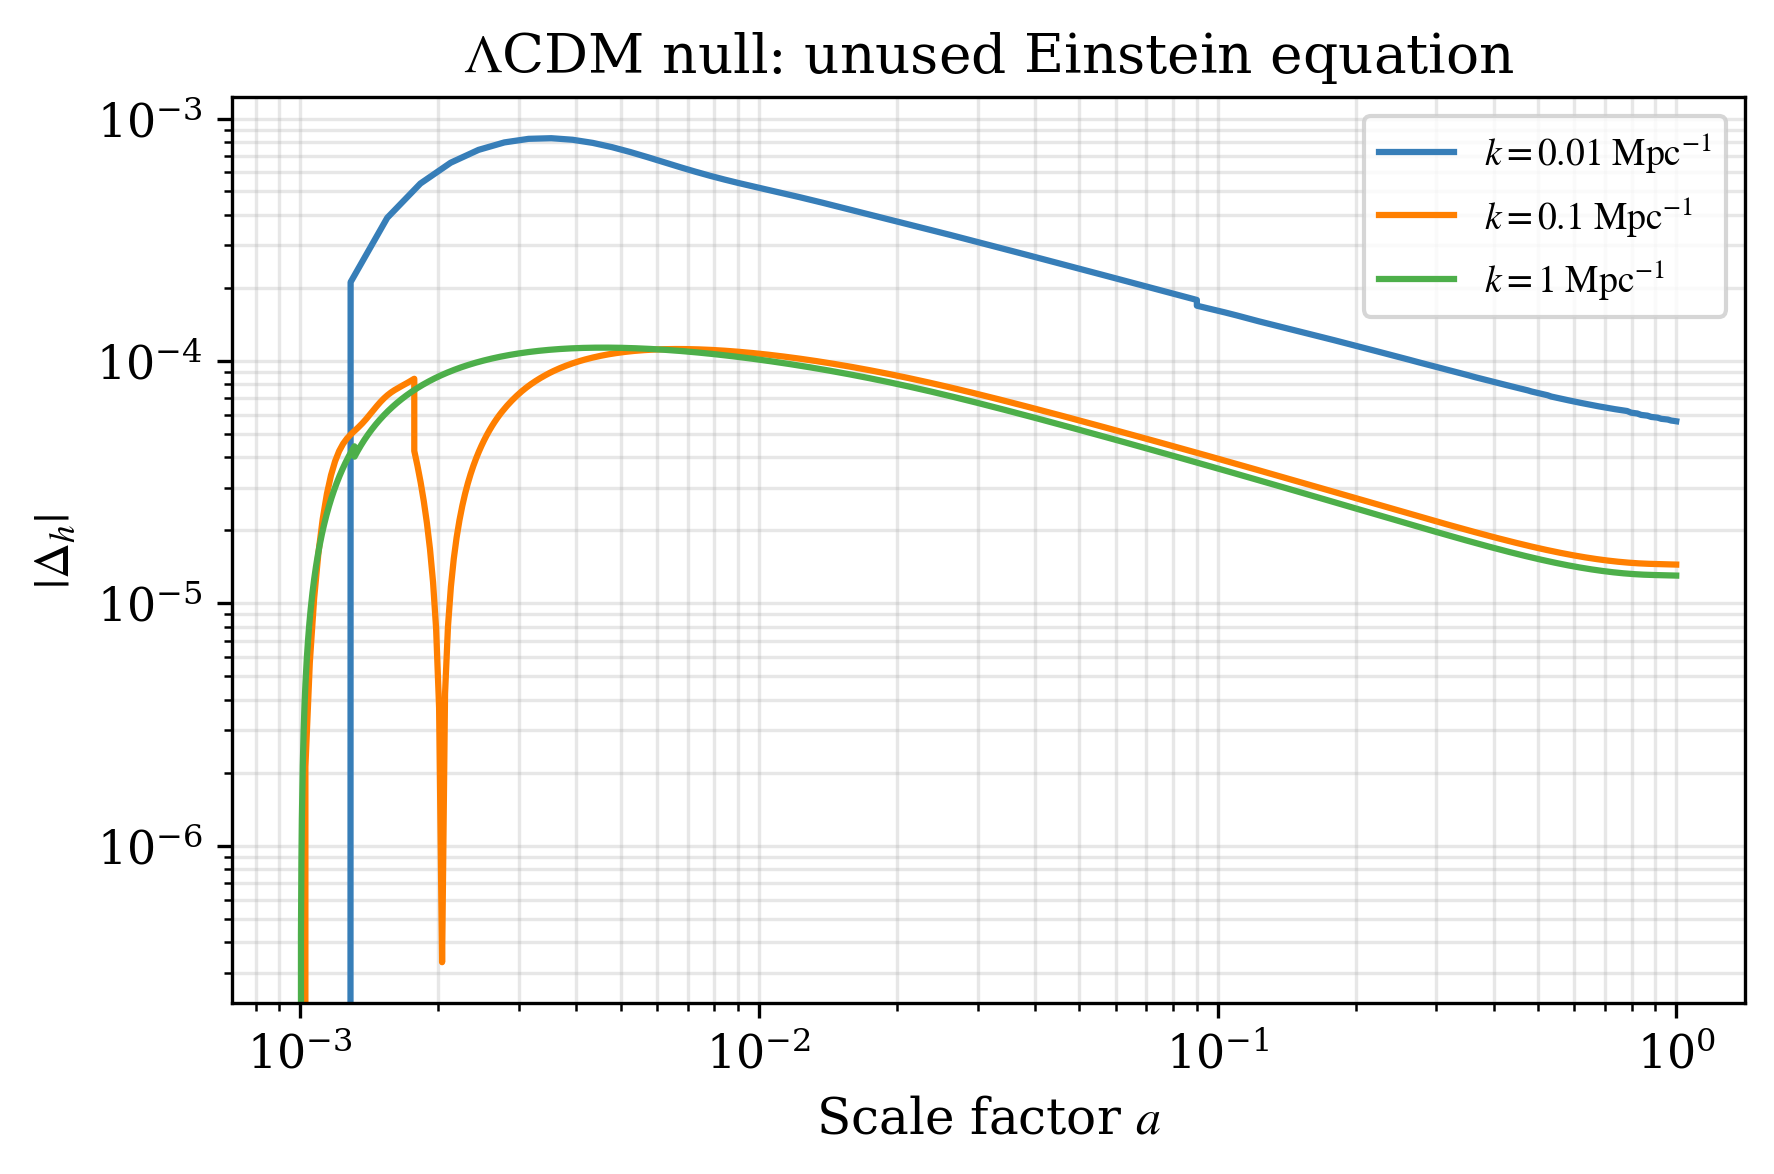

In [4]:
drift_l = {kk: trace_drift(pk, bg_l, kk, 0.0) for kk, pk in zip(K_OUT, perts_l)}

print('LCDM NULL TEST - drift of the trace equation')
print('  ncdm fluid approximation:', NCDM_FLUID, '  (RSA/UFA at CLASS defaults)')
print('  {:>8} {:>8} {:>13} {:>10} {:>15} {:>13}'.format(
      'k', 'n_pts', 'max|Delta_h|', 'a at max', '|Delta_h| at a=1', 'quad error'))
for kk in K_OUT:
    d = drift_l[kk]
    print('  {:>8g} {:>8d} {:>13.3e} {:>10.4f} {:>15.3e} {:>13.3e}'.format(
          kk, d['n_pts'], d['max_abs'], d['a_at_max'],
          float(np.abs(d['Delta_h'][-1])), d['quad_err']))
print('  quad error = Richardson estimate (full grid vs every other point) on the')
print('  same trapezoid rule we report, i.e. an error bar on the answer itself.')

NULL_H = max(float(np.max(np.abs(drift_l[kk]['Delta_h']))) for kk in K_OUT)
print('\n  null floor: {:.3e}'.format(NULL_H))
print('  (a large value here means the 9*a^2*delta_p coefficient or the units are wrong,')
print('   not that LCDM violates GR - check patch (b) landed on ppw->delta_p)')

fig, ax = plt.subplots(figsize=(5.8, 3.8), constrained_layout=True)
for color, kk in zip(qual_colors, K_OUT):
    ax.loglog(drift_l[kk]['a'], np.abs(drift_l[kk]['Delta_h']), color=color,
              label=r'$k = {:g}\ \mathrm{{Mpc}}^{{-1}}$'.format(kk))
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\Delta_h|$')
ax.set_title(r'$\Lambda$CDM null: unused Einstein equation')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## accDM

If the background result carries over, the drift should switch on at $a_t$ and then persist, with a
magnitude tracking the predicted $\int 3a^2\sum\delta Q/\mathcal{H}\,\mathrm{d}\tau$.

Note this probes a genuinely different thing from the background test: $\sum\delta Q$ is weighted by
$\delta_{\rm parent}$, which is $k$-dependent and grows, whereas the background violation is weighted
by $\rho_{\rm parent}$ alone. A $k$-dependent drift is the signature that the inconsistency is not
just a background rescaling.


accDM hierarchy ~ 9348 equations (daughter q-bins = 501, l_max_ncdm = 17), evolver = rk
accDM {'f_acc': 0.1, 'eta': 0.1, 'kappa': 12.1, 'a_t': 0.133}
        k  max|Delta_h|         at a=1  predicted a=1     pre-inj  meas/pred
     0.01     3.618e-02     +6.246e-03     +6.304e-03    8.29e-04      0.991
      0.1     4.640e-02     +7.120e-03     +6.328e-03    1.11e-04      1.125
        1     4.721e-02     +7.138e-03     +6.331e-03    1.13e-04      1.127
  pre-inj = |Delta_h| in the window a < a_t/2, i.e. this run's own floor

  LCDM null at a=1, per k: 0.01: 5.64e-05, 0.1: 1.45e-05, 1: 1.30e-05
  The verdict cell combines these with the quad error into a per-k error bar.


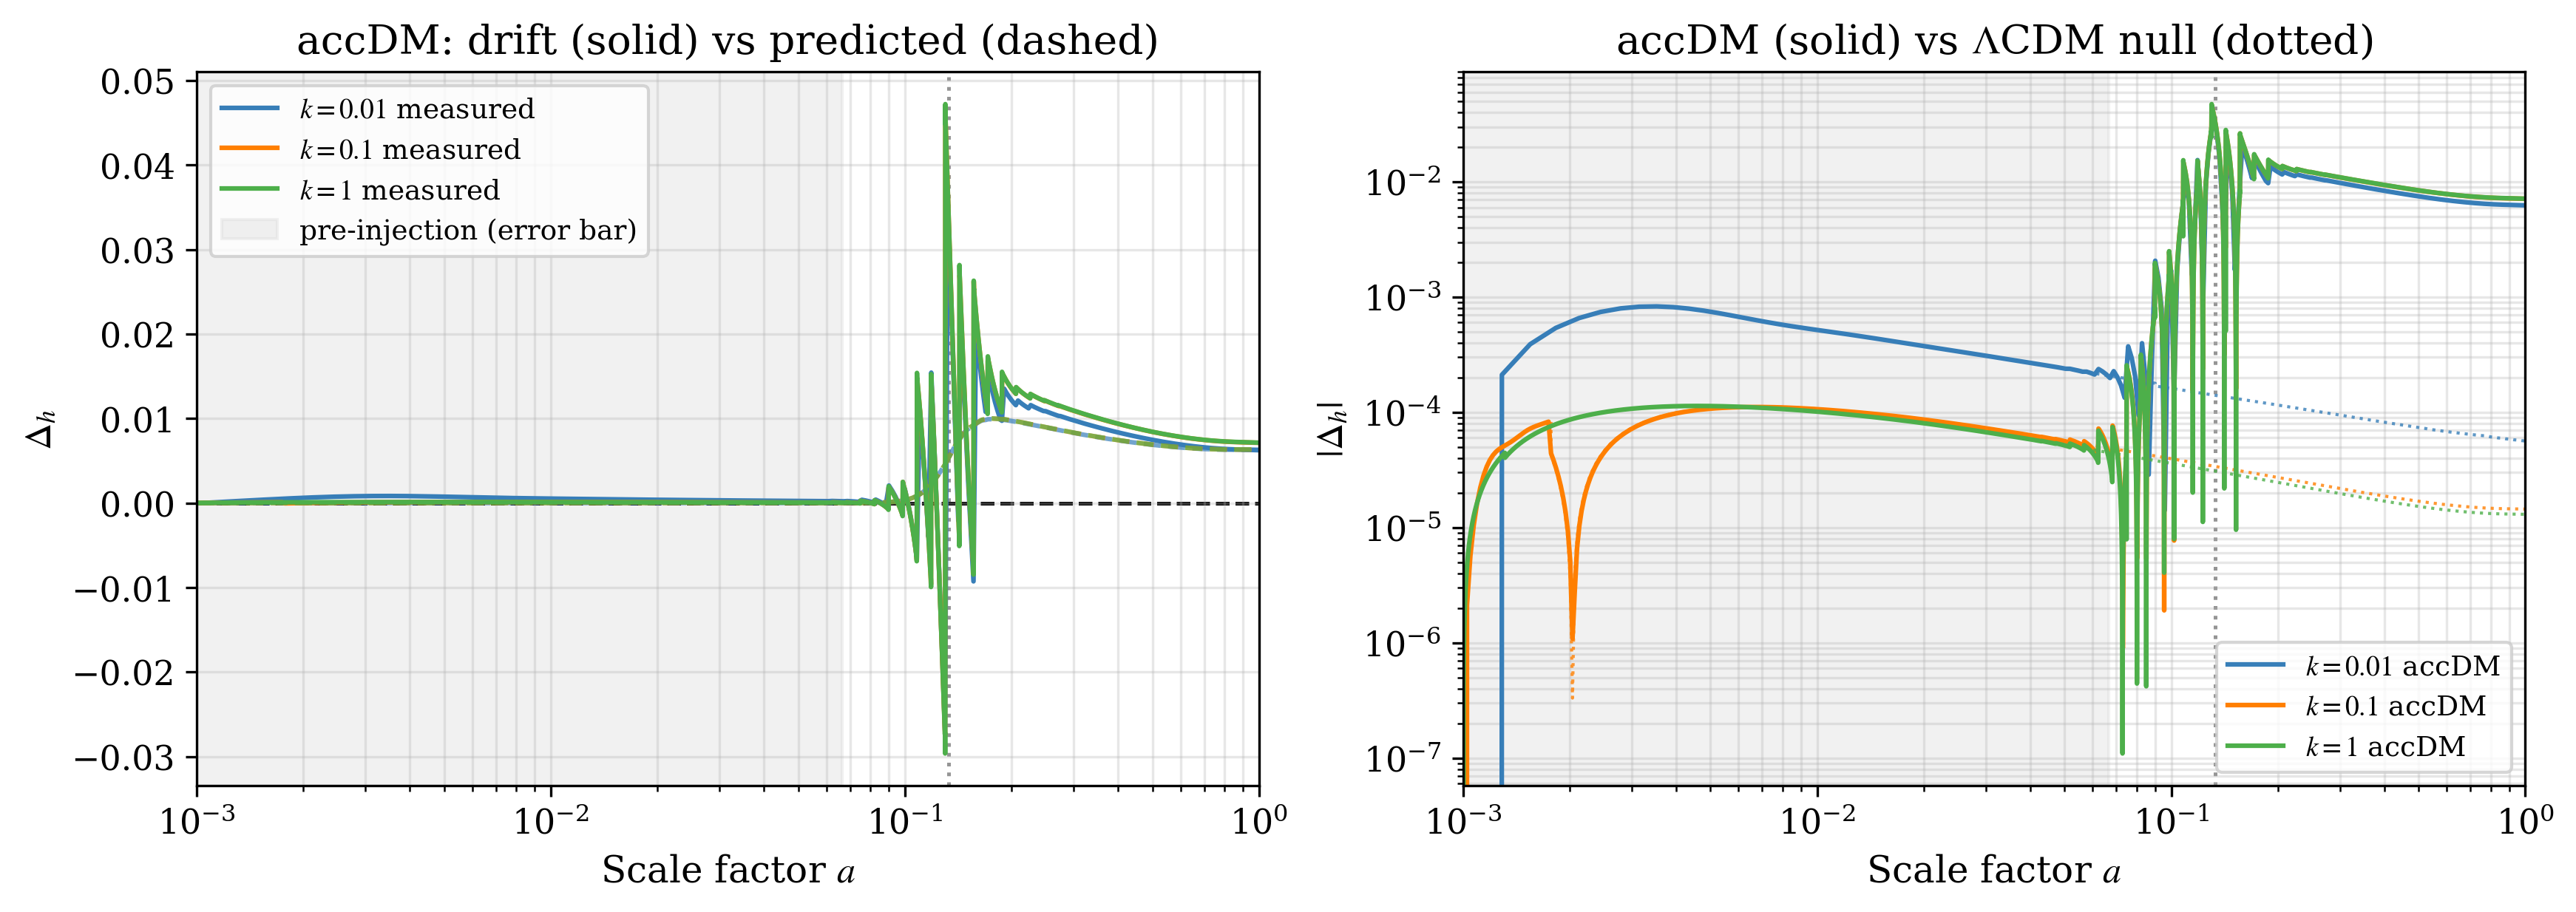

In [5]:
pa = accdm_params(**FIDUCIAL)
print('accDM hierarchy ~ {:d} equations (daughter q-bins = {:d}, l_max_ncdm = {:d}), evolver = {}'
      .format(hierarchy_size(pa), N_Q_DAUGHTER, L_MAX_NCDM, 'rk' if EVOLVER == 0 else 'ndf15'))
perts_a, bg_a = run(pa)
drift_a = {kk: trace_drift(pk, bg_a, kk, FIDUCIAL['eta'])
           for kk, pk in zip(K_OUT, perts_a)}

print('accDM', FIDUCIAL)
print('  {:>7} {:>13} {:>14} {:>14} {:>11} {:>10}'.format(
      'k', 'max|Delta_h|', 'at a=1', 'predicted a=1', 'pre-inj', 'meas/pred'))
for kk in K_OUT:
    d = drift_a[kk]
    meas, pred = float(d['Delta_h'][-1]), float(d['Delta_pred'][-1])
    print('  {:>7g} {:>13.3e} {:>+14.3e} {:>+14.3e} {:>11.2e} {:>10.3f}'.format(
          kk, d['max_abs'], meas, pred, preinjection_floor(d, FIDUCIAL['a_t']),
          meas/pred if pred != 0 else float('nan')))
print('  pre-inj = |Delta_h| in the window a < a_t/2, i.e. this run\'s own floor')
print('\n  LCDM null at a=1, per k: ' +
      ', '.join('{:g}: {:.2e}'.format(kk, abs(float(drift_l[kk]['Delta_h'][-1])))
                for kk in K_OUT))
print('  The verdict cell combines these with the quad error into a per-k error bar.')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)

ax = axes[0]
for color, kk in zip(qual_colors, K_OUT):
    ax.semilogx(drift_a[kk]['a'], drift_a[kk]['Delta_h'], color=color,
                label=r'$k = {:g}$ measured'.format(kk))
    ax.semilogx(drift_a[kk]['a'], drift_a[kk]['Delta_pred'], color=color,
                linestyle='--', alpha=0.7)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.axvspan(A_START, 0.5*FIDUCIAL['a_t'], color='0.85', alpha=0.35, zorder=0,
           label='pre-injection (error bar)')
ax.set_xlim(A_START, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Delta_h$')
ax.set_title(r'accDM: drift (solid) vs predicted (dashed)')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for color, kk in zip(qual_colors, K_OUT):
    ax.loglog(drift_a[kk]['a'], np.abs(drift_a[kk]['Delta_h']), color=color,
              label=r'$k = {:g}$ accDM'.format(kk))
    ax.loglog(drift_l[kk]['a'], np.abs(drift_l[kk]['Delta_h']), color=color,
              linestyle=':', linewidth=1.0, alpha=0.8)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.axvspan(A_START, 0.5*FIDUCIAL['a_t'], color='0.85', alpha=0.35, zorder=0)
ax.set_xlim(A_START, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\Delta_h|$')
ax.set_title(r'accDM (solid) vs $\Lambda$CDM null (dotted)')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## Chasing the `meas/pred` offset

The measured drift comes out consistently above the prediction built from
$\sum\delta Q = \eta\,a\Gamma\rho_{\rm parent}\delta_{\rm parent}$. Two facts narrow it down:

- The offset is **unchanged** between the exact hierarchy and the fluid daughter, so it is not the
  difference between those two code paths.
- Converting the fluid-branch $\delta$ equation (`perturbations.c:10190`) to $\delta\rho_d'$ makes the
  $\delta_{\rm daughter}$ terms cancel *exactly* against the $(1+\eta)a\Gamma\rho_c$ term in
  $\rho_d'$, leaving $\delta Q_{\rm daughter} = (1+\eta)a\Gamma\rho_c\delta_c$ - so the prediction is
  algebraically right **provided** the daughter's background actually obeys

  $$\rho_d' = -3\mathcal{H}(\rho_d + p_d) + (1+\eta)\,a\,\Gamma_{\rm acc}\,\rho_{\rm parent}. \tag{B}$$

But $\rho_d$ is not evolved from (B) - it is built by quadrature over the constructed $f_0$. If the
two disagree, the cancellation above is incomplete and an extra $\delta Q$ appears, which is exactly
the kind of thing that would show up as a constant multiplicative offset.

So: test (B) directly. Background only, and differentiation-free - integrate it rather than
differentiating the staircase that $\rho_{\rm ncdm}$ is:

$$G(x) = \bigl[\rho_d\bigr]_{x_0}^{x} + \int_{x_0}^{x} 3(\rho_d + p_d)\,\mathrm{d}x'
- (1+\eta)\!\int_{x_0}^{x}\!\frac{\Gamma_{\rm acc}\rho_{\rm parent}}{H}\,\mathrm{d}x' \;\overset{!}{=}\; 0 .$$

Rather than just reporting $G$, solve for the coefficient the background *actually* realises,

$$1+\eta_{\rm eff} \;=\; \frac{\bigl[\rho_d\bigr]_{x_0}^{x} + \int 3(\rho_d+p_d)\,\mathrm{d}x'}
{\int \Gamma_{\rm acc}\rho_{\rm parent}/H\,\mathrm{d}x'},$$

and compare with $1+\eta$. If that ratio is 1, the background is clean and the offset lives in the
perturbation sector (pinning ICs for the exact daughter, or the $c_{\rm eff}^2$ closure feeding
$\delta p_{\rm tot}$ for the fluid one). If it is not 1, we have found it.


Does the daughter background obey  rho_d' = -3H(rho_d+p_d) + (1+eta) a Gamma rho_c ?
  1+eta as specified          : 1.100000
  1+eta_eff realised (a=1)    : 1.101666
  ratio realised / specified  : 1.0015

  meas/pred from the perturbation test, for comparison:
    k = 0.01   : 0.991
    k = 0.1    : 1.125
    k = 1      : 1.127

  If these two match, the perturbation offset is inherited from the background
  bookkeeping. If the background ratio is ~1, the offset is genuinely in the
  perturbation sector and the background is exonerated.


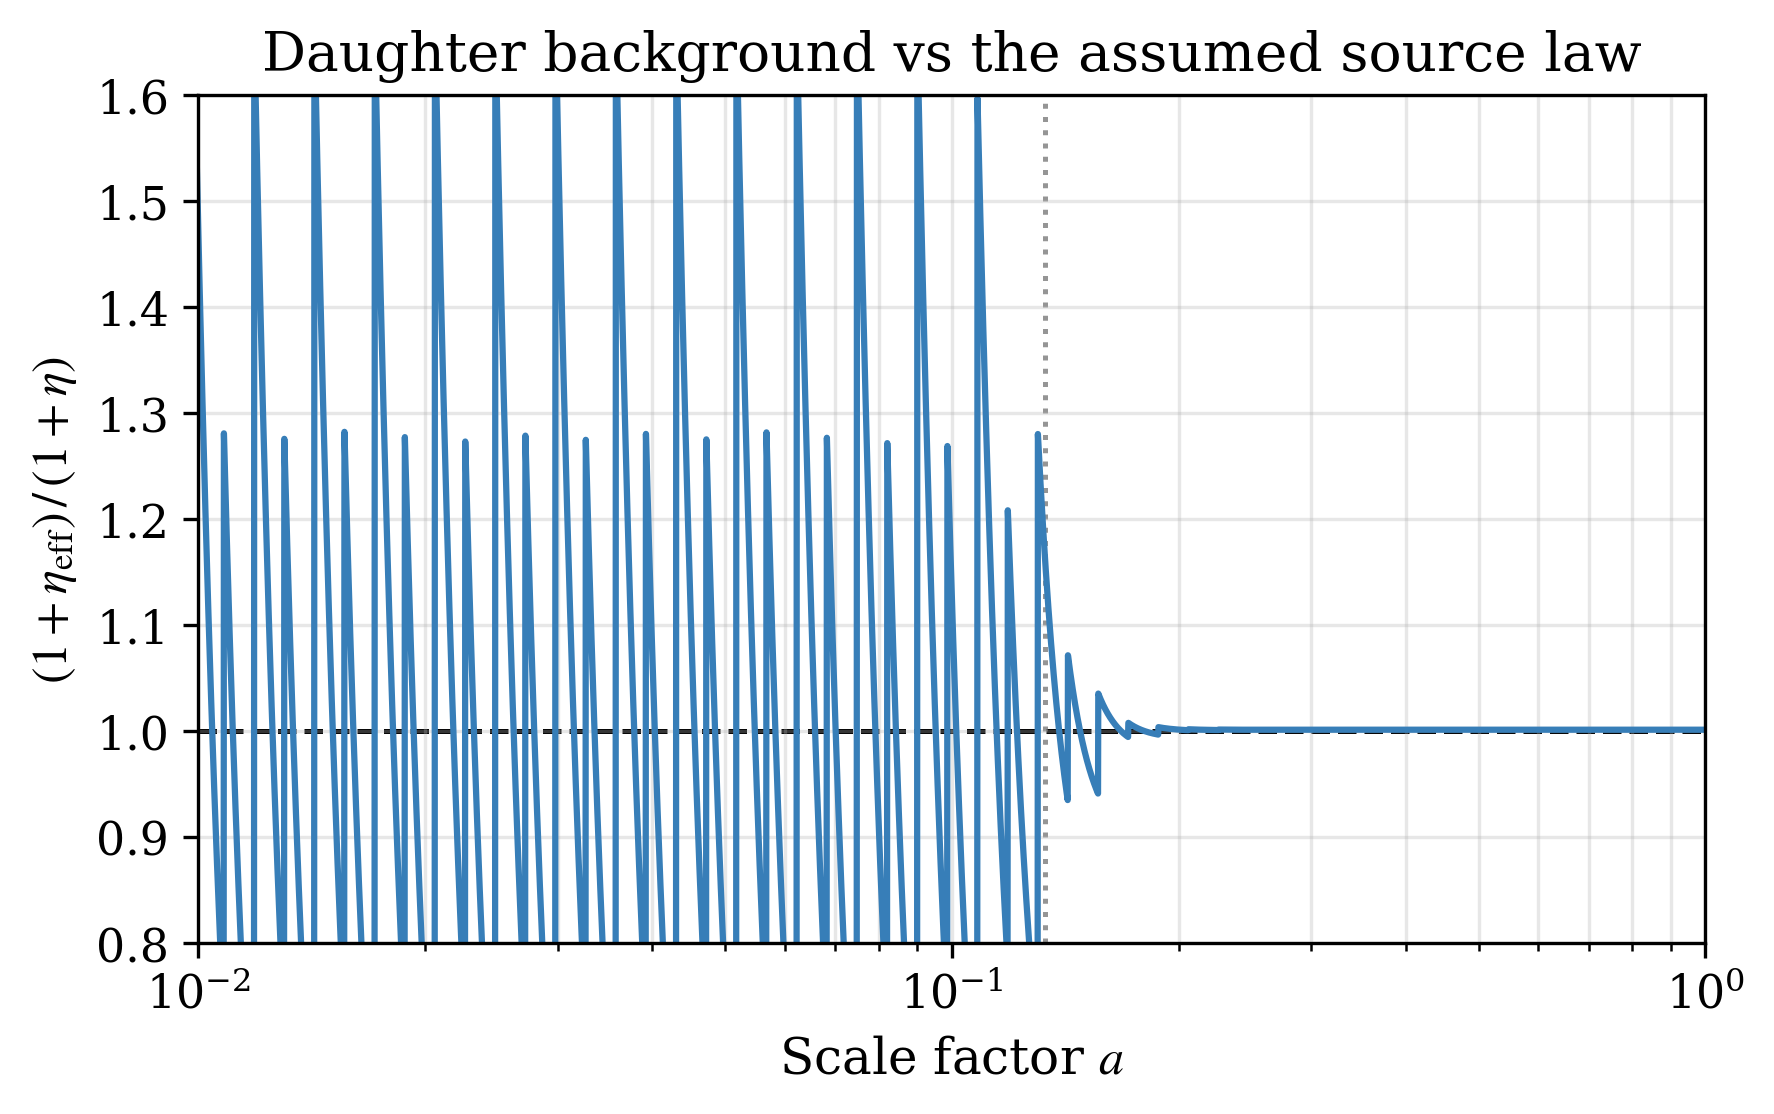

In [6]:
def background_source_consistency(f_acc, eta, kappa, a_t, a_start=A_START, n_q=None):
    '''Does the daughter's tabulated background obey equation (B)?'''
    p = accdm_params(f_acc=f_acc, eta=eta, kappa=kappa, a_t=a_t, n_q=n_q)
    for key in ('output', 'k_output_values', 'P_k_max_1/Mpc', 'z_max_pk'):
        p.pop(key, None)                      # background only: fast
    cosmo = Class(); cosmo.set(p); cosmo.compute()
    bg = cosmo.get_background(); cosmo.struct_cleanup(); cosmo.empty()

    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]
    idx   = max(int(k.split('[')[1].split(']')[0])
                for k in bg if k.startswith('(.)rho_ncdm['))

    a     = a_all[order]
    sel   = a >= a_start
    a     = a[sel]
    x     = np.log(a)
    rho_d = take('(.)rho_ncdm[{:d}]'.format(idx))[sel]
    p_d   = take('(.)p_ncdm[{:d}]'.format(idx))[sel]
    rho_c = take('(.)rho_acc_cdm')[sel]
    gam   = take('Gamma_acc')[sel]
    H     = take('H [1/Mpc]')[sel]

    lhs = (rho_d - rho_d[0]) + cum_trapz(3.0*(rho_d + p_d), x)
    inj = cum_trapz(gam*rho_c/H, x)
    ok  = inj > 0
    return dict(a=a[ok], one_plus_eta_eff=lhs[ok]/inj[ok], target=1.0 + eta,
                final=float(lhs[ok][-1]/inj[ok][-1]))


chk = background_source_consistency(**FIDUCIAL)
print('Does the daughter background obey  rho_d\' = -3H(rho_d+p_d) + (1+eta) a Gamma rho_c ?')
print('  1+eta as specified          : {:.6f}'.format(chk['target']))
print('  1+eta_eff realised (a=1)    : {:.6f}'.format(chk['final']))
print('  ratio realised / specified  : {:.4f}'.format(chk['final']/chk['target']))
print()
print('  meas/pred from the perturbation test, for comparison:')
for kk in K_OUT:
    d = drift_a[kk]
    pred = float(d['Delta_pred'][-1])
    print('    k = {:<6g} : {:.3f}'.format(
          kk, float(d['Delta_h'][-1])/pred if pred != 0 else float('nan')))
print()
print('  If these two match, the perturbation offset is inherited from the background')
print('  bookkeeping. If the background ratio is ~1, the offset is genuinely in the')
print('  perturbation sector and the background is exonerated.')

fig, ax = plt.subplots(figsize=(5.8, 3.6), constrained_layout=True)
ax.semilogx(chk['a'], chk['one_plus_eta_eff']/chk['target'], color=qual_colors[0])
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(max(A_START, 1e-2), 1.0)
ax.set_ylim(0.8, 1.6)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$(1+\eta_{\mathrm{eff}})\,/\,(1+\eta)$')
ax.set_title('Daughter background vs the assumed source law')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## Verdict


In [7]:
print('=' * 78)
print('PERTURBATION-LEVEL CONSISTENCY - trace equation (MB 21c)')
print('=' * 78)
print()
print('Validation:')
print('  ncdm fluid approximation (both legs)          : {}'.format(NCDM_FLUID))
print('  imposed-constraint residual, median            : {:.3e}'.format(med_norm))
print('  labelled/swapped ratio (column mapping)       : {:.3e}'.format(med_norm/med_swap))
print('  LCDM null, max |Delta_h| over all k           : {:.3e}'.format(NULL_H))
print()
print('accDM at', FIDUCIAL)
print('  Error bar = the accDM run\'s OWN pre-injection plateau (a < a_t/2), where')
print('  nothing physical is happening, taken with the Richardson quad error in case')
print('  the quadrature is ever the larger. The LCDM null is printed for reference')
print('  only: it is a different run without the daughter, and it sits one to two')
print('  orders lower, so using it would overstate the significance.')
print('  {:>7} {:>14} {:>10} {:>10} {:>10} {:>10} {:>6} {:>10}'.format(
      'k', 'Delta_h(a=1)', 'pre-inj', 'quad err', 'error bar', 'LCDM null',
      'S/N', 'meas/pred'))
worst = 0.0
worst_snr = None
for kk in K_OUT:
    d, n = drift_a[kk], drift_l[kk]
    meas, pred = float(d['Delta_h'][-1]), float(d['Delta_pred'][-1])
    null_k = abs(float(n['Delta_h'][-1]))
    qerr   = d['quad_err']
    floor  = preinjection_floor(d, FIDUCIAL['a_t'])
    err    = max(0.0 if np.isnan(floor) else floor,
                 0.0 if np.isnan(qerr) else qerr)
    snr    = abs(meas)/max(err, 1e-300)
    worst  = max(worst, abs(meas))
    worst_snr = snr if worst_snr is None else min(worst_snr, snr)
    print('  {:>7g} {:>+14.3e} {:>10.2e} {:>10.2e} {:>10.2e} {:>10.2e} {:>6.0f} {:>10.3f}'.format(
          kk, meas, floor, qerr, err, null_k, snr,
          meas/pred if pred != 0 else float('nan')))
print()
print('  largest |Delta_h| = {:.3e};  weakest S/N over the sampled k = {:.0f}'.format(
      worst, worst_snr))
print()
print('Interpretation: Delta_h is the fractional error accumulated in h_prime by the')
print('Einstein equation CLASS computes but never uses to evolve h_prime. It is the')
print('perturbation analogue of the background Delta.')
print()
print('Expect it to be nearly k-INDEPENDENT. In synchronous gauge the parent obeys')
print('delta_c\' = -h\'/2 exactly (theta_c = 0, no metric-euler term), so')
print('delta_parent = -h/2 and the source tracks h itself; normalising by max|h\'|')
print('divides the k-dependence back out. Consequence: over this k range the')
print('inconsistency acts as an amplitude shift, largely degenerate with A_s/sigma8,')
print('rather than a shape distortion. Modes still super-horizon at a_t (roughly')
print('k < 2e-4 /Mpc) are not covered by that argument and are worth one check.')
print()
print('Caveat: this measures the internal inconsistency, not an observable shift. The')
print('observable question stays what it was - C_l and P(k), current code vs a fixed')
print('version - and the cheapest fixed background remains')
print('    m_acc_in_GeV = m_cdm_in_GeV * sqrt(1 - eta*(eta+2)),')
print('valid for eta < sqrt(2)-1, which conserves energy exactly at background level')
print('while leaving the hardcoded (1+eta) in the perturbation sources.')
print('=' * 78)


PERTURBATION-LEVEL CONSISTENCY - trace equation (MB 21c)

Validation:
  ncdm fluid approximation (both legs)          : none
  imposed-constraint residual, median            : 4.801e-09
  labelled/swapped ratio (column mapping)       : 4.829e-09
  LCDM null, max |Delta_h| over all k           : 8.294e-04

accDM at {'f_acc': 0.1, 'eta': 0.1, 'kappa': 12.1, 'a_t': 0.133}
  Error bar = the accDM run's OWN pre-injection plateau (a < a_t/2), where
  nothing physical is happening, taken with the Richardson quad error in case
  the quadrature is ever the larger. The LCDM null is printed for reference
  only: it is a different run without the daughter, and it sits one to two
  orders lower, so using it would overstate the significance.
        k   Delta_h(a=1)    pre-inj   quad err  error bar  LCDM null    S/N  meas/pred
     0.01     +6.246e-03   8.29e-04   5.03e-04   8.29e-04   5.64e-05      8      0.991
      0.1     +7.120e-03   1.11e-04   9.27e-06   1.11e-04   1.45e-05     64      1.125
 